# Block 0: Environment & Imports

In [ ]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, List, Tuple, Optional

# ----  auto-install missing packages ----
import sys, subprocess
def _ensure_package(pkg: str):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure_package("mne")
_ensure_package("scipy")
_ensure_package("sklearn")

import mne
from scipy.signal import butter, filtfilt, welch
from scipy.integrate import simpson

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)

# ---- Colab: mount drive ----
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Not in Colab. Skipping drive.mount().")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ===== Paths =====
CHB01_DIR = "/content/drive/MyDrive/chb01"
SUMMARY_FILE = "/content/drive/MyDrive/chb01-summary.txt"

# ===== Main pipeline params =====
EPOCH_LEN_S = 2.0
W = 3

# Feature bands (Hz)
BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}

# Main preprocessing for modelling (preserve beta up to 30 Hz)
MAIN_BANDPASS = (0.5, 30.0)

# Debug plots
DEBUG_PLOTS = False  # True if you want extra figures


Mounted at /content/drive


# Block 1: List EDFs + Parse summary into dict

In [ ]:
def list_edf_files(folder: str) -> List[str]:
    edf_paths = sorted(glob.glob(os.path.join(folder, "*.edf")))
    if not edf_paths:
        raise FileNotFoundError(f"No EDF files found in: {folder}")
    return edf_paths

def parse_summary_to_dict(summary_path: str) -> Dict[str, List[Tuple[float, float]]]:
    """
    Parse chb01-summary.txt to:
      seizure_dict[file_name] = [(start_s, end_s), ...]
    """
    with open(summary_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f.readlines()]

    seizure_dict: Dict[str, List[Tuple[float, float]]] = {}
    current_file = None
    starts: List[float] = []
    ends: List[float] = []

    def _flush():
        nonlocal current_file, starts, ends
        if current_file is None:
            return
        seizure_dict[current_file] = list(zip(starts, ends))
        starts, ends = [], []

    for line in lines:
        m_file = re.match(r"File Name:\s*(.*)", line)
        if m_file:
            _flush()
            current_file = m_file.group(1).strip()
            continue

        m_s = re.match(r"Seizure Start Time:\s*(\d+)\s*seconds", line)
        m_e = re.match(r"Seizure End Time:\s*(\d+)\s*seconds", line)
        if m_s and current_file is not None:
            starts.append(float(m_s.group(1)))
        if m_e and current_file is not None:
            ends.append(float(m_e.group(1)))

    _flush()
    return seizure_dict

edf_paths = list_edf_files(CHB01_DIR)
seizure_dict = parse_summary_to_dict(SUMMARY_FILE)

print(f"Found EDF files: {len(edf_paths)}")
print("Example EDFs:", [os.path.basename(p) for p in edf_paths[:5]])

# Quick check: how many EDFs have at least one seizure?
edf_with_seiz = [fn for fn, intervals in seizure_dict.items() if intervals]
print(f"EDFs with seizures in summary: {len(edf_with_seiz)} (example: {edf_with_seiz[:5]})")


Found EDF files: 42
Example EDFs: ['chb01_01.edf', 'chb01_02.edf', 'chb01_03.edf', 'chb01_04.edf', 'chb01_05.edf']
EDFs with seizures in summary: 7 (example: ['chb01_03.edf', 'chb01_04.edf', 'chb01_15.edf', 'chb01_16.edf', 'chb01_18.edf'])


# Block 2: Core helper functions (bandpass, segmentation, labels, features, stacking)

In [ ]:
def bandpass_filter_multich(
    data: np.ndarray,  # shape (C, N)
    fs: float,
    l_freq: float,
    h_freq: float,
    order: int = 4
) -> np.ndarray:
    """
    IIR bandpass filter (Butterworth + filtfilt) for multichannel EEG data.
    Uses zero-phase filtering to prevent phase shifting.
    """
    nyq = 0.5 * fs
    low = l_freq / nyq
    high = h_freq / nyq
    b, a = butter(order, [low, high], btype="band")
    # filtfilt supports axis=-1 for 2D arrays, ensuring fast row-wise filtering
    return filtfilt(b, a, data, axis=-1)

def segment_eeg_into_epochs(
    eeg: np.ndarray,   # (C, N)
    sfreq: float,
    epoch_len_s: float
) -> Dict[str, object]:
    """
    Segments continuous EEG data into fixed-length epochs (e.g., 2 seconds).
    """
    epoch_len_samples = int(epoch_len_s * sfreq)
    C, N = eeg.shape
    n_epochs = N // epoch_len_samples

    # Trim the trailing data that doesn't fit into a full epoch
    trimmed = eeg[:, : n_epochs * epoch_len_samples]
    # Reshape and transpose to get shape: (Epochs, Channels, Samples)
    epochs = trimmed.reshape(C, n_epochs, epoch_len_samples).transpose(1, 0, 2)

    start_samples = np.arange(n_epochs) * epoch_len_samples
    end_samples = start_samples + epoch_len_samples

    return {
        "epochs": epochs,
        "sfreq": sfreq,
        "epoch_len_s": epoch_len_s,
        "epoch_len_samples": epoch_len_samples,
        "epoch_start_times": start_samples / sfreq,
        "epoch_end_times": end_samples / sfreq,
        "n_epochs": n_epochs
    }

def create_labels_from_intervals(
    seg: Dict[str, object],
    seizure_intervals: List[Tuple[float, float]]
) -> np.ndarray:
    """
    Assigns binary labels (1=seizure, 0=normal) to each epoch
    based on the provided seizure interval timestamps.
    """
    y = np.zeros(seg["n_epochs"], dtype=int)
    if not seizure_intervals:
        return y

    for i in range(seg["n_epochs"]):
        t0 = seg["epoch_start_times"][i]
        t1 = seg["epoch_end_times"][i]
        # If the epoch overlaps with any seizure interval, label it as 1
        for (s, e) in seizure_intervals:
            if (t0 < e) and (t1 > s):
                y[i] = 1
                break
    return y

# === Upgraded Feature Extraction (Includes Line Length & Hjorth) =======
def extract_spatial_features_all_epochs(
    epochs: np.ndarray,   # (E, C, S)
    fs: float,
    bands: Dict[str, Tuple[float, float]]
) -> np.ndarray:
    """
    Fast feature extraction using FULL vectorization.
    Extracts 7 features per channel:
      1-4: PSD Band Energies (Delta, Theta, Alpha, Beta)
      5:   RMS (Root Mean Square - Signal Amplitude)
      6:   Line Length (Signal complexity and sharpness)
      7:   Hjorth Complexity (Spike detection)
    Output:
      X_spatial shape = (E, C*7)
    """
    E, C, S = epochs.shape
    eps = 1e-12  # Small epsilon to prevent division by zero in dead channels

    # ================= Frequency Domain Features (Welch PSD) =================
    freqs, psd = welch(epochs, fs=fs, nperseg=S, axis=-1)  # psd: (E, C, F)

    feat_list = []
    for (f_low, f_high) in bands.values():
        idx = (freqs >= f_low) & (freqs < f_high)
        # Integrate PSD over frequency axis -> (E, C)
        be = simpson(psd[..., idx], freqs[idx], axis=-1) if np.any(idx) else np.zeros((E, C))
        feat_list.append(be)

    # ================= Time Domain Feature 1: RMS =================
    # Root Mean Square (RMS) calculation along the time axis: (E,C)
    rms = np.sqrt(np.mean(epochs ** 2, axis=-1))
    feat_list.append(rms)

    # ================= Time Domain Feature 2: Line Length (New) =================
    # Calculate absolute differences between adjacent points along the time axis (axis=-1)
    # and sum them up. Result shape: (E,C)
    line_length = np.sum(np.abs(np.diff(epochs, axis=-1)), axis=-1)
    feat_list.append(line_length)

    # ================= Time Domain Feature 3: Hjorth Complexity (New) =================
    # Vectorized calculation of 0th, 1st, and 2nd order standard deviations
    std_x = np.std(epochs, axis=-1)                      # 0th order SD (Original Signal)

    dx = np.diff(epochs, axis=-1)                        # 1st order derivative (Velocity)
    std_dx = np.std(dx, axis=-1)                         # 1st order SD

    ddx = np.diff(dx, axis=-1)                           # 2nd order derivative (Acceleration)
    std_ddx = np.std(ddx, axis=-1)                       # 2nd order SD

    # Calculate Hjorth Mobility and Complexity
    mobility_x = std_dx / (std_x + eps)
    mobility_dx = std_ddx / (std_dx + eps)
    hjorth_complexity = mobility_dx / (mobility_x + eps) # Result shape: (E,C)

    feat_list.append(hjorth_complexity)

    # ================= Data Aggregation and Flattening =================
    # Stack features -> (E, C, 7) then reshape/flatten -> (E, C*7)
    feat_3d = np.stack(feat_list, axis=-1)  # (E, C, 7)
    X_spatial = feat_3d.reshape(E, C * feat_3d.shape[-1])
    return X_spatial

def temporal_stack_within_file(
    X_spatial: np.ndarray,  # (E, F) -> F is now C*7
    y_epoch: np.ndarray,    # (E,)
    W: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Stacks W consecutive epochs to capture temporal context (memory).
    Important: Stacking must NOT cross EDF file boundaries to prevent data leakage.
    X_final(t) = [X(t-W+1),...,X(t)] flattened
    y_final(t) is aligned to the label of the last epoch y(t).
    """
    E, F = X_spatial.shape
    if E < W:
        return np.empty((0, W * F)), np.empty((0,), dtype=int)

    # Use sliding window to stack features
    X_final = np.vstack([X_spatial[i-(W-1):i+1].reshape(-1) for i in range(W-1, E)])
    y_final = np.array([y_epoch[i] for i in range(W-1, E)], dtype=int)
    return X_final, y_final

# Block 3 (Optional): Sanity check figure (raw vs filtered + PSD)

In [ ]:
def sanity_check_plot_one_channel(edf_path: str, ch_name: Optional[str] = None,
                                  bp=(0.5, 12.5), n_seconds=10):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    fs = raw.info["sfreq"]
    chs = raw.ch_names

    if ch_name is None:
        ch_name = chs[0]

    x = raw.get_data(picks=[ch_name]).squeeze()
    x_f = filtfilt(*butter(4, [bp[0]/(0.5*fs), bp[1]/(0.5*fs)], btype="band"), x)

    n = int(fs * n_seconds)
    t = np.arange(n) / fs

    plt.figure(figsize=(12,3))
    plt.plot(t, x[:n])
    plt.title(f"Raw EEG (first {n_seconds}s) - {ch_name}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(t, x_f[:n])
    plt.title(f"Filtered EEG {bp[0]}–{bp[1]} Hz (first {n_seconds}s) - {ch_name}")
    plt.grid(True)
    plt.show()

    f0, p0 = welch(x, fs=fs, nperseg=int(fs*2))
    f1, p1 = welch(x_f, fs=fs, nperseg=int(fs*2))
    plt.figure(figsize=(10,4))
    plt.semilogy(f0, p0, label="Raw")
    plt.semilogy(f1, p1, label="Filtered")
    plt.title("PSD compare (Welch): raw vs filtered")
    plt.xlabel("Hz"); plt.ylabel("PSD"); plt.grid(True); plt.legend()
    plt.show()

    raw.close()

if DEBUG_PLOTS:
    sanity_check_plot_one_channel(edf_paths[0], ch_name=None, bp=(0.5, 12.5), n_seconds=10)


# Block 4 (Optional): Per-channel PSD plot (diagnostic)

In [ ]:
def plot_multichannel_psd_one_epoch(edf_path: str, epoch_len_s=2.0):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    fs = raw.info["sfreq"]
    data = raw.get_data()  # (C,N)

    # main bandpass for modelling (0.5–30) to make PSD more interpretable
    data_bp = bandpass_filter_multich(data, fs, MAIN_BANDPASS[0], MAIN_BANDPASS[1], order=4)

    seg = segment_eeg_into_epochs(data_bp, fs, epoch_len_s)
    ep0 = seg["epochs"][0]  # (C,S)

    plt.figure(figsize=(10,5))
    for c in range(ep0.shape[0]):
        f, p = welch(ep0[c], fs=fs, nperseg=ep0.shape[1])
        plt.semilogy(f, p, linewidth=0.7)
    plt.title("Multichannel PSD (Welch) - first epoch")
    plt.xlabel("Hz"); plt.ylabel("PSD"); plt.grid(True)
    plt.show()

    raw.close()

if DEBUG_PLOTS:
    plot_multichannel_psd_one_epoch(edf_paths[0], epoch_len_s=EPOCH_LEN_S)


# Block 5: Build dataset across ALL EDFs (within-file stacking only)

In [ ]:
MAX_FILES = None  # set e.g. 5 for quick testing; None = use all

X_list = []
y_list = []
groups_list = []   # file-name per sample (for group split)
meta_rows = []     # optional: per-file stats

# Choose a reference channel order from the first file to ensure consistent feature dimension
raw0 = mne.io.read_raw_edf(edf_paths[0], preload=False, verbose=False)
REF_CH_NAMES = raw0.ch_names
raw0.close()

print(f"Reference channels: C={len(REF_CH_NAMES)}")

use_paths = edf_paths if MAX_FILES is None else edf_paths[:MAX_FILES]

for k, path in enumerate(use_paths, 1):
    file_name = os.path.basename(path)
    seizure_intervals = seizure_dict.get(file_name, [])  # may be empty

    try:
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        fs = raw.info["sfreq"]

        # Ensure channel set is consistent
        if not all(ch in raw.ch_names for ch in REF_CH_NAMES):
            print(f"[Skip] {file_name}: channel set mismatch.")
            raw.close()
            continue

        # Reorder to REF_CH_NAMES
        raw.pick(REF_CH_NAMES)

        data = raw.get_data()  # (C,N)

        # Main bandpass for modelling (preserves beta up to 30 Hz)
        data_bp = bandpass_filter_multich(data, fs, MAIN_BANDPASS[0], MAIN_BANDPASS[1], order=4)

        seg = segment_eeg_into_epochs(data_bp, fs, EPOCH_LEN_S)
        epochs = seg["epochs"]  # (E,C,S)

        # Labels at epoch-level
        y_epoch = create_labels_from_intervals(seg, seizure_intervals)

        # Spatial features for all epochs
        X_spatial = extract_spatial_features_all_epochs(epochs, fs, BANDS)  # (E, C*5)

        # Temporal stacking within the file (no cross-file leakage)
        X_final, y_final = temporal_stack_within_file(X_spatial, y_epoch, W=W)

        if len(y_final) == 0:
            print(f"[Skip] {file_name}: too few epochs for W={W}.")
            raw.close()
            continue

        X_list.append(X_final)
        y_list.append(y_final)
        groups_list.append(np.array([file_name] * len(y_final), dtype=object))

        meta_rows.append({
            "file": file_name,
            "sfreq": fs,
            "n_epochs": seg["n_epochs"],
            "n_samples_stacked": len(y_final),
            "seizure_intervals": str(seizure_intervals),
            "pos_epochs": int(y_epoch.sum()),
            "pos_samples_stacked": int(y_final.sum())
        })

        print(f"[{k}/{len(use_paths)}] {file_name}: stacked samples={len(y_final)}, positives={int(y_final.sum())}")

        raw.close()

    except Exception as e:
        print(f"[Error] {file_name}: {e}")
        try:
            raw.close()
        except Exception:
            pass

# Aggregate
X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
groups_all = np.concatenate(groups_list)

meta_df = pd.DataFrame(meta_rows)

# save the data in npz
save_path = "/content/drive/MyDrive/chb01_processed_data.npz"

np.savez_compressed(
    save_path,
    X=X_all,
    y=y_all,
    groups=groups_all
)
print(f"\n The data has been successfully saved as a npz format: {save_path}")
meta_df.head()


/tmp/ipython-input-1703870850.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw0 = mne.io.read_raw_edf(edf_paths[0], preload=False, verbose=False)
/tmp/ipython-input-1703870850.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Reference channels: C=23
[1/42] chb01_01.edf: stacked samples=1798, positives=0


/tmp/ipython-input-1703870850.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


[2/42] chb01_02.edf: stacked samples=1798, positives=0


/tmp/ipython-input-1703870850.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


...

/tmp/ipython-input-1703870850.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


[41/42] chb01_43.edf: stacked samples=1798, positives=0


/tmp/ipython-input-1703870850.py:22: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


[42/42] chb01_46.edf: stacked samples=1798, positives=0

 The data has been successfully saved as a npz format: /content/drive/MyDrive/chb01_processed_data.npz


,file,sfreq,n_epochs,n_samples_stacked,seizure_intervals,pos_epochs,pos_samples_stacked
0,chb01_01.edf,256.0,1800,1798,[],0,0
1,chb01_02.edf,256.0,1800,1798,[],0,0
2,chb01_03.edf,256.0,1800,1798,"[(2996.0, 3036.0)]",20,20
3,chb01_04.edf,256.0,1800,1798,"[(1467.0, 1494.0)]",14,14
4,chb01_05.edf,256.0,1800,1798,[],0,0


# Block 6: Dataset overview (overall + per-file)

In [ ]:
print("=== Overall dataset ===")
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Positives:", int((y_all == 1).sum()), "/", len(y_all), "pos rate =", float((y_all==1).mean()))

print("\n=== Per-file summary (top 10) ===")
display_cols = ["file", "n_samples_stacked", "pos_samples_stacked", "seizure_intervals"]
print(meta_df[display_cols].sort_values("pos_samples_stacked", ascending=False).head(10).to_string(index=False))

# Optional: plot distribution of positives per file
if DEBUG_PLOTS:
    plt.figure(figsize=(10,4))
    plt.bar(meta_df["file"], meta_df["pos_samples_stacked"])
    plt.xticks(rotation=90)
    plt.title("Positive stacked samples per EDF file")
    plt.ylabel("Count")
    plt.grid(True, axis="y")
    plt.show()


=== Overall dataset ===
X_all shape: (72909, 483)
y_all shape: (72909,)
Positives: 223 / 72909 pos rate = 0.0030586073049966396

=== Per-file summary (top 10) ===
        file  n_samples_stacked  pos_samples_stacked  seizure_intervals
chb01_26.edf               1160                   51 [(1862.0, 1963.0)]
chb01_21.edf               1798                   47   [(327.0, 420.0)]
chb01_18.edf               1798                   45 [(1720.0, 1810.0)]
chb01_16.edf               1798                   26 [(1015.0, 1066.0)]
chb01_03.edf               1798                   20 [(2996.0, 3036.0)]
chb01_15.edf               1798                   20 [(1732.0, 1772.0)]
chb01_04.edf               1798                   14 [(1467.0, 1494.0)]
chb01_02.edf               1798                    0                 []
chb01_05.edf               1798                    0                 []
chb01_01.edf               1798                    0                 []


# Block 7: Group split (avoid leakage) with positive-check

In [ ]:
def group_split_with_positive(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    test_size: float = 0.30,
    base_seed: int = 42,
    max_tries: int = 50
):
    """
    Try multiple random seeds to ensure both train/test contain positives.
    If cannot, fallback to stratified split (with warning).
    """
    unique_groups = np.unique(groups)
    print(f"Unique EDF files (groups): {len(unique_groups)}")

    for i in range(max_tries):
        seed = base_seed + i
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        (train_idx, test_idx) = next(gss.split(X, y, groups))

        y_train, y_test = y[train_idx], y[test_idx]
        if (y_train.sum() > 0) and (y_test.sum() > 0):
            print(f"[Group split OK] random_state={seed} | train pos={int(y_train.sum())}, test pos={int(y_test.sum())}")
            return train_idx, test_idx

    print(" Could not find a group split with positives in both train and test.")
    print(" Falling back to stratified random split (may introduce temporal leakage).")
    train_idx, test_idx = train_test_split(
        np.arange(len(y)),
        test_size=test_size,
        random_state=base_seed,
        stratify=y
    )
    return train_idx, test_idx

train_idx, test_idx = group_split_with_positive(X_all, y_all, groups_all, test_size=0.30, base_seed=RANDOM_STATE)

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print("Train size:", len(y_train), "| Test size:", len(y_test))
print("Train positives:", int(y_train.sum()), "| Test positives:", int(y_test.sum()))


Unique EDF files (groups): 42
[Group split OK] random_state=42 | train pos=127, test pos=96
Train size: 52142 | Test size: 20767
Train positives: 127 | Test positives: 96


# Block 8: Scale + Train SVM

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)

print("Training SVM ...")
clf.fit(X_train_s, y_train)
print("Done.")


Training SVM ...
Done.


# Block 9: Basic evaluation (report / CM / ROC-AUC)


[1] Classification report
                 precision    recall  f1-score   support

Non-Seizure (0)       1.00      1.00      1.00     20671
    Seizure (1)       1.00      0.05      0.10        96

       accuracy                           1.00     20767
      macro avg       1.00      0.53      0.55     20767
   weighted avg       1.00      1.00      0.99     20767

[2] Confusion matrix


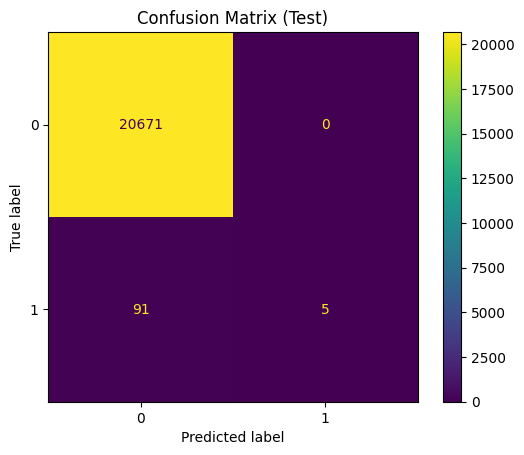

[3] ROC-AUC = 0.9975


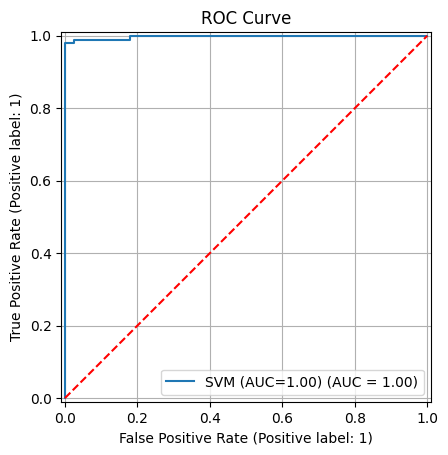

In [ ]:
y_pred = clf.predict(X_test_s)
y_score = clf.predict_proba(X_test_s)[:, 1]

print("\n[1] Classification report")
print(classification_report(
    y_test, y_pred,
    target_names=["Non-Seizure (0)", "Seizure (1)"],
    zero_division=0
))

print("[2] Confusion matrix")
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=["0","1"]).plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

# ROC/AUC needs both classes in y_test
if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_score)
    print(f"[3] ROC-AUC = {auc:.4f}")
    RocCurveDisplay.from_predictions(y_test, y_score, name=f"SVM (AUC={auc:.2f})")
    plt.plot([0,1], [0,1], "r--")
    plt.grid(True)
    plt.title("ROC Curve")
    plt.show()
else:
    print("[3] ROC-AUC skipped: y_test has only one class.")


# Block 10: Evaluation extensions (naive baseline / PR-AP / threshold sweep)


--- (A) Naive baseline: predict all 0 ---
Naive CM:
 [[20671     0]
 [   96     0]]
Naive accuracy=0.9954, Naive balanced accuracy=0.5000

--- (B) PR curve & AP ---
Average Precision (AP) = 0.8836


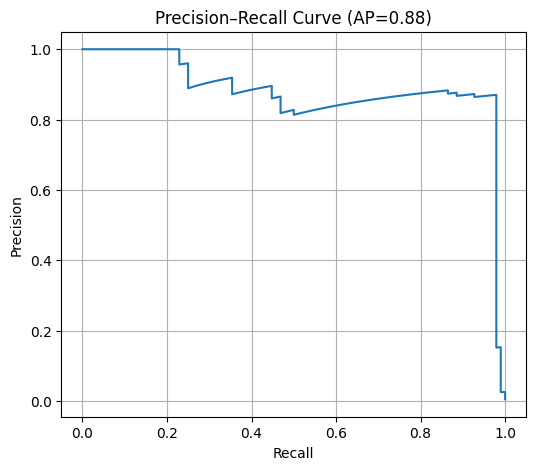


--- (C) Threshold sweep ---

Candidate operating point (recall>0, best balanced_acc):
threshold           0.100000
precision           0.138081
recall              0.989583
fpr                 0.028688
balanced_acc        0.980448
tp                 95.000000
fp                593.000000
fn                  1.000000
tn              20078.000000
Name: 10, dtype: float64


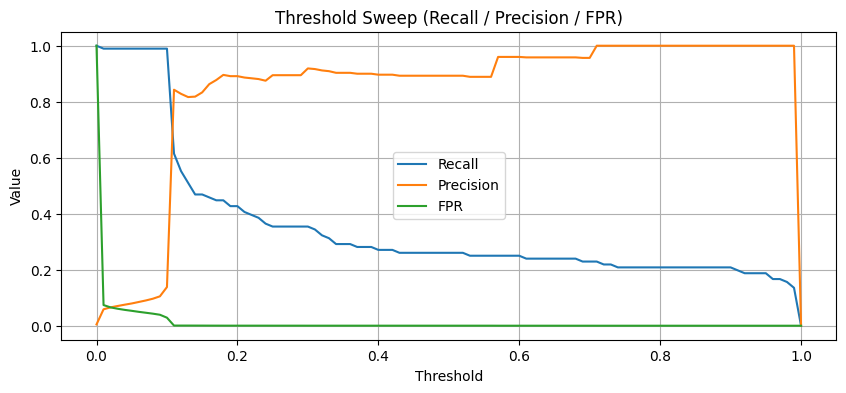

In [ ]:
print("\n--- (A) Naive baseline: predict all 0 ---")
y_pred_naive = np.zeros_like(y_test)
cm_naive = confusion_matrix(y_test, y_pred_naive, labels=[0,1])
tn, fp, fn, tp = cm_naive.ravel()
acc_naive = (tn + tp) / cm_naive.sum()
tpr = tp / (tp + fn + 1e-12)
tnr = tn / (tn + fp + 1e-12)
bal_acc_naive = 0.5 * (tpr + tnr)
print("Naive CM:\n", cm_naive)
print(f"Naive accuracy={acc_naive:.4f}, Naive balanced accuracy={bal_acc_naive:.4f}")

# PR/AP needs both classes
if len(np.unique(y_test)) == 2:
    print("\n--- (B) PR curve & AP ---")
    precision, recall, thr = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    print(f"Average Precision (AP) = {ap:.4f}")

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve (AP={ap:.2f})")
    plt.grid(True)
    plt.show()

    print("\n--- (C) Threshold sweep ---")
    thresholds = np.linspace(0.0, 1.0, 101)
    rows = []
    for th in thresholds:
        y_hat = (y_score >= th).astype(int)
        cm_t = confusion_matrix(y_test, y_hat, labels=[0,1])
        tn, fp, fn, tp = cm_t.ravel()

        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        fpr  = fp / (fp + tn + 1e-12)
        tnr  = tn / (tn + fp + 1e-12)
        bal  = 0.5 * (rec + tnr)

        rows.append([th, prec, rec, fpr, bal, tp, fp, fn, tn])

    scan_df = pd.DataFrame(rows, columns=["threshold","precision","recall","fpr","balanced_acc","tp","fp","fn","tn"])

    cand = scan_df[scan_df["recall"] > 0]
    if len(cand) > 0:
        best = cand.sort_values("balanced_acc", ascending=False).iloc[0]
        print("\nCandidate operating point (recall>0, best balanced_acc):")
        print(best)
    else:
        print("\nNo threshold achieved recall > 0 on this test set.")

    plt.figure(figsize=(10,4))
    plt.plot(scan_df["threshold"], scan_df["recall"], label="Recall")
    plt.plot(scan_df["threshold"], scan_df["precision"], label="Precision")
    plt.plot(scan_df["threshold"], scan_df["fpr"], label="FPR")
    plt.xlabel("Threshold")
    plt.ylabel("Value")
    plt.title("Threshold Sweep (Recall / Precision / FPR)")
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("\nPR/AP and threshold sweep skipped: y_test has only one class (no positives in test).")


# Level 2: new patient B

In [ ]:
# ==========================================================
# Step 1: Prepare data paths for Patient B (chb02)
# ==========================================================
CHB02_DIR = "/content/drive/MyDrive/chb02"
SUMMARY_FILE_02 = "/content/drive/MyDrive/chb02/chb02-summary.txt"

# Retrieve all EDF files and seizure timestamps for chb02
edf_paths_02 = list_edf_files(CHB02_DIR)
seizure_dict_02 = parse_summary_to_dict(SUMMARY_FILE_02)

X_list_02 = []
y_list_02 = []

print("=== Starting Feature Extraction for Patient B (chb02) ===")

# ==========================================================
# Step 2: Process Patient B's data using the exact pipeline used for Patient A
# ==========================================================
for path in edf_paths_02: # Note: Add [:3] here to test only the first 3 files for debugging
    file_name = os.path.basename(path)
    seizure_intervals = seizure_dict_02.get(file_name, [])

    try:
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        fs = raw.info["sfreq"]

        # [Golden Rule 1]: If Patient B is missing any channel used by Patient A, skip the file.
        # Strict channel matching is required for the model to work.
        if not all(ch in raw.ch_names for ch in REF_CH_NAMES):
            print(f"Channel mismatch, skipping: {file_name}")
            continue

        # Force reordering of channels to match the reference montage
        raw.pick(REF_CH_NAMES)
        data = raw.get_data()

        # [Replicate Pipeline]: Filter -> Segment -> Label -> Extract 7 Features -> Temporal Stack
        data_bp = bandpass_filter_multich(data, fs, MAIN_BANDPASS[0], MAIN_BANDPASS[1])
        seg = segment_eeg_into_epochs(data_bp, fs, EPOCH_LEN_S)
        y_ep = create_labels_from_intervals(seg, seizure_intervals)
        X_sp = extract_spatial_features_all_epochs(seg["epochs"], fs, BANDS)
        X_fin, y_fin = temporal_stack_within_file(X_sp, y_ep, W=W)

        X_list_02.append(X_fin)
        y_list_02.append(y_fin)
        raw.close()
    except Exception as e:
        print(f"Error processing {file_name}: {e}")

# Aggregate the large feature matrix for Patient B
X_B = np.vstack(X_list_02)
y_B = np.concatenate(y_list_02)
print(f"Patient B data ready! Total samples: {len(y_B)}, Seizure samples: {int(y_B.sum())}")

# ==========================================================
# Step 3: Predict using Patient A's model and scaler
# ==========================================================
# [Golden Rule 2]: Use the PRE-FITTED scaler from Patient A!
# Do NOT fit a new scaler on Patient B, or the data distribution will shift.
X_B_scaled = scaler.transform(X_B)

# Get probability scores predicted by the AI
y_B_score = clf.predict_proba(X_B_scaled)[:, 1]

# Calculate AUC on Patient B (Generalization Test)
auc_B = roc_auc_score(y_B, y_B_score)
print(f"\n[Test Result] Patient B AUROC: {auc_B:.4f}")

# ==========================================================
# Step 4: Generate final report using the 0.10 threshold
# ==========================================================
# [Golden Rule 3]: Stick to the optimal threshold (0.10) found in Block 10
BEST_THRESHOLD = 0.10

# Classify as seizure only if probability >= 0.10
y_B_pred = (y_B_score >= BEST_THRESHOLD).astype(int)

print(f"\n=== Performance on Patient B using Threshold {BEST_THRESHOLD} ===")
print(classification_report(y_B, y_B_pred))

=== Starting Feature Extraction for Patient B (chb02) ===


/tmp/ipython-input-3344677591.py:24: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-3344677591.py:24: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-3344677591.py:24: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-3344677591.py:24: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-3344677591.py:24: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Appl

Patient B data ready! Total samples: 63407, Seizure samples: 87

[Test Result] Patient B AUROC: 0.9277

=== Performance on Patient B using Threshold 0.1 ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     63320
           1       0.01      0.95      0.02        87

    accuracy                           0.87     63407
   macro avg       0.50      0.91      0.47     63407
weighted avg       1.00      0.87      0.93     63407



In [ ]:
# =============================================================================
# Step 1: Target Domain Data Initialization (Patient B / chb02)
# =============================================================================
CHB02_DIR = "/content/drive/MyDrive/chb02"
SUMMARY_FILE_02 = "/content/drive/MyDrive/chb02/chb02-summary.txt"

# Index all EDF files and parse seizure annotations for ground truth generation
edf_paths_02 = list_edf_files(CHB02_DIR)
seizure_dict_02 = parse_summary_to_dict(SUMMARY_FILE_02)

X_list_02 = []
y_list_02 = []

print(f"[INFO] Initiating Feature Extraction Pipeline for Target Subject: {os.path.basename(CHB02_DIR)}")

# =============================================================================
# Step 2: Feature Engineering & Preprocessing Pipeline
# =============================================================================
# Iterating through each recording session
for path in edf_paths_02:
    # [DEV NOTE]: For rapid debugging, slice edf_paths_02[:3] to process only first 3 files.
    file_name = os.path.basename(path)
    seizure_intervals = seizure_dict_02.get(file_name, [])

    try:
        # Load raw EEG data into memory
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        fs = raw.info["sfreq"]

        # [CRITICAL VALIDATION]: Channel Montage Consistency Check
        # The model's input layer expects a specific channel order. Any deviation invalidates the inference.
        # Strict policy: If any reference channel is missing, discard the entire recording.
        if not all(ch in raw.ch_names for ch in REF_CH_NAMES):
            print(f"[WARNING] Channel Mismatch Detected in {file_name}. Skipping file to maintain feature integrity.")
            continue

        # Enforce Reference Montage: Select and reorder channels to match training data
        raw.pick(REF_CH_NAMES)
        data = raw.get_data()

        # [PIPELINE REPLICATION]: Apply identical transformations as Source Domain
        # 1. Bandpass Filtering (0.5-30Hz) - Noise reduction & Artifact removal
        data_bp = bandpass_filter_multich(data, fs, MAIN_BANDPASS[0], MAIN_BANDPASS[1])

        # 2. Segmentation - Windowing into fixed-length epochs
        seg = segment_eeg_into_epochs(data_bp, fs, EPOCH_LEN_S)

        # 3. Label Assignment - Ground Truth generation
        y_ep = create_labels_from_intervals(seg, seizure_intervals)

        # 4. Feature Extraction - Computing spatial-spectral features
        X_sp = extract_spatial_features_all_epochs(seg["epochs"], fs, BANDS)

        # 5. Temporal Stacking - Incorporating temporal context (Memory Window W)
        X_fin, y_fin = temporal_stack_within_file(X_sp, y_ep, W=W)

        X_list_02.append(X_fin)
        y_list_02.append(y_fin)

        # Clear memory
        raw.close()

    except Exception as e:
        print(f"[ERROR] Failed to process {file_name}. Reason: {e}")

# Data Aggregation: Stacking all sessions into a single Feature Matrix (X) and Label Vector (y)
if not X_list_02:
    raise ValueError("No valid data extracted. Please check file paths and channel names.")

X_B = np.vstack(X_list_02)
y_B = np.concatenate(y_list_02)
print(f"[INFO] Data Aggregation Complete. Total Samples: {len(y_B)} | Seizure Samples: {int(y_B.sum())}")

# =============================================================================
# Step 3: Inference (Model Evaluation)
# =============================================================================
# [CRITICAL PROCEDURE]: Feature Standardization
# We must use the scaler fitted on Patient A (Source Domain) to transform Patient B (Target Domain).
# Fitting a new scaler on B would destroy the learned decision boundary relative to the feature magnitudes.
print("[INFO] Applying Source Domain Scaler transform...")
X_B_scaled = scaler.transform(X_B)

# Generate Prediction Probabilities
print("[INFO] Executing Model Inference...")
y_B_score = clf.predict_proba(X_B_scaled)[:, 1]

# Calculate Generalization Performance (AUROC)
auc_B = roc_auc_score(y_B, y_B_score)
print(f"\n[RESULTS] Cross-Subject Generalization AUROC: {auc_B:.4f}")

# =============================================================================
# Step 4: Clinical Metrics Calculation
# =============================================================================
# [DECISION THRESHOLD]: Applying the optimal operating point determined in validation phase.
# Threshold = 0.10 (Optimized for High Sensitivity)
OPERATING_THRESHOLD = 0.10

# Binarize predictions based on operating threshold
y_B_pred = (y_B_score >= OPERATING_THRESHOLD).astype(int)

print(f"\n{'='*20} CLINICAL PERFORMANCE REPORT (Patient B) {'='*20}")
print(f"Operating Point (Threshold): {OPERATING_THRESHOLD}")
print("-" * 60)
print(classification_report(y_B, y_B_pred))
print("="*60)

[INFO] Initiating Feature Extraction Pipeline for Target Subject: chb02


/tmp/ipython-input-1394249636.py:27: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-1394249636.py:27: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-1394249636.py:27: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-1394249636.py:27: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipython-input-1394249636.py:27: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Appl

[INFO] Data Aggregation Complete. Total Samples: 63407 | Seizure Samples: 87
[INFO] Applying Source Domain Scaler transform...
[INFO] Executing Model Inference...

[RESULTS] Cross-Subject Generalization AUROC: 0.9277

==================== CLINICAL PERFORMANCE REPORT (Patient B) ====================
Operating Point (Threshold): 0.1
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     63320
           1       0.01      0.95      0.02        87

    accuracy                           0.87     63407
   macro avg       0.50      0.91      0.47     63407
weighted avg       1.00      0.87      0.93     63407

